for sensor  reservoir_stor_4001_sof24 start_num is:  155567
train set total length is :  236664
看看使用了全体数据的均值还是训练数据
236664
结束》》》》》》》》》》》》》》》》》》》》》》》》》》》》》》》》
mean is:  0.000877445154967278
std is  3.855830028757664
oversampling thresholds are:  -0.2466077208518982 0.20206351578235626
norm is:  [8.77445155e-04 3.85583003e+00]
Begin to generate val_dataloader!
Validation DATA shape,  (60, 360, 3)
Validation Label,  (60, 72, 3)
val set saved to :  ./output/Almaden/val/validation_timestamps_24avg.tsv
Begin to generate train_dataloader!
Train DATA shape,  (56000, 360, 3)
Train Label,  (56000, 72, 3)
训练集数据的选取长度是：  56000
训练集标签的选取长度是：  56000
[Route Quantiles] q50=2.849976, q80=5.970837, q95=19.300018
route_labels shape: (56000,)
route label counts: [44800 11200]
刷新数据集********************
for sensor  reservoir_stor_4001_sof24 start_num is:  155567
train set total length is :  236664
[TEST] 构建测试集...
刷新数据集********************
for sensor  reservoir_stor_4001_sof24 start_num is:  155567
train set to

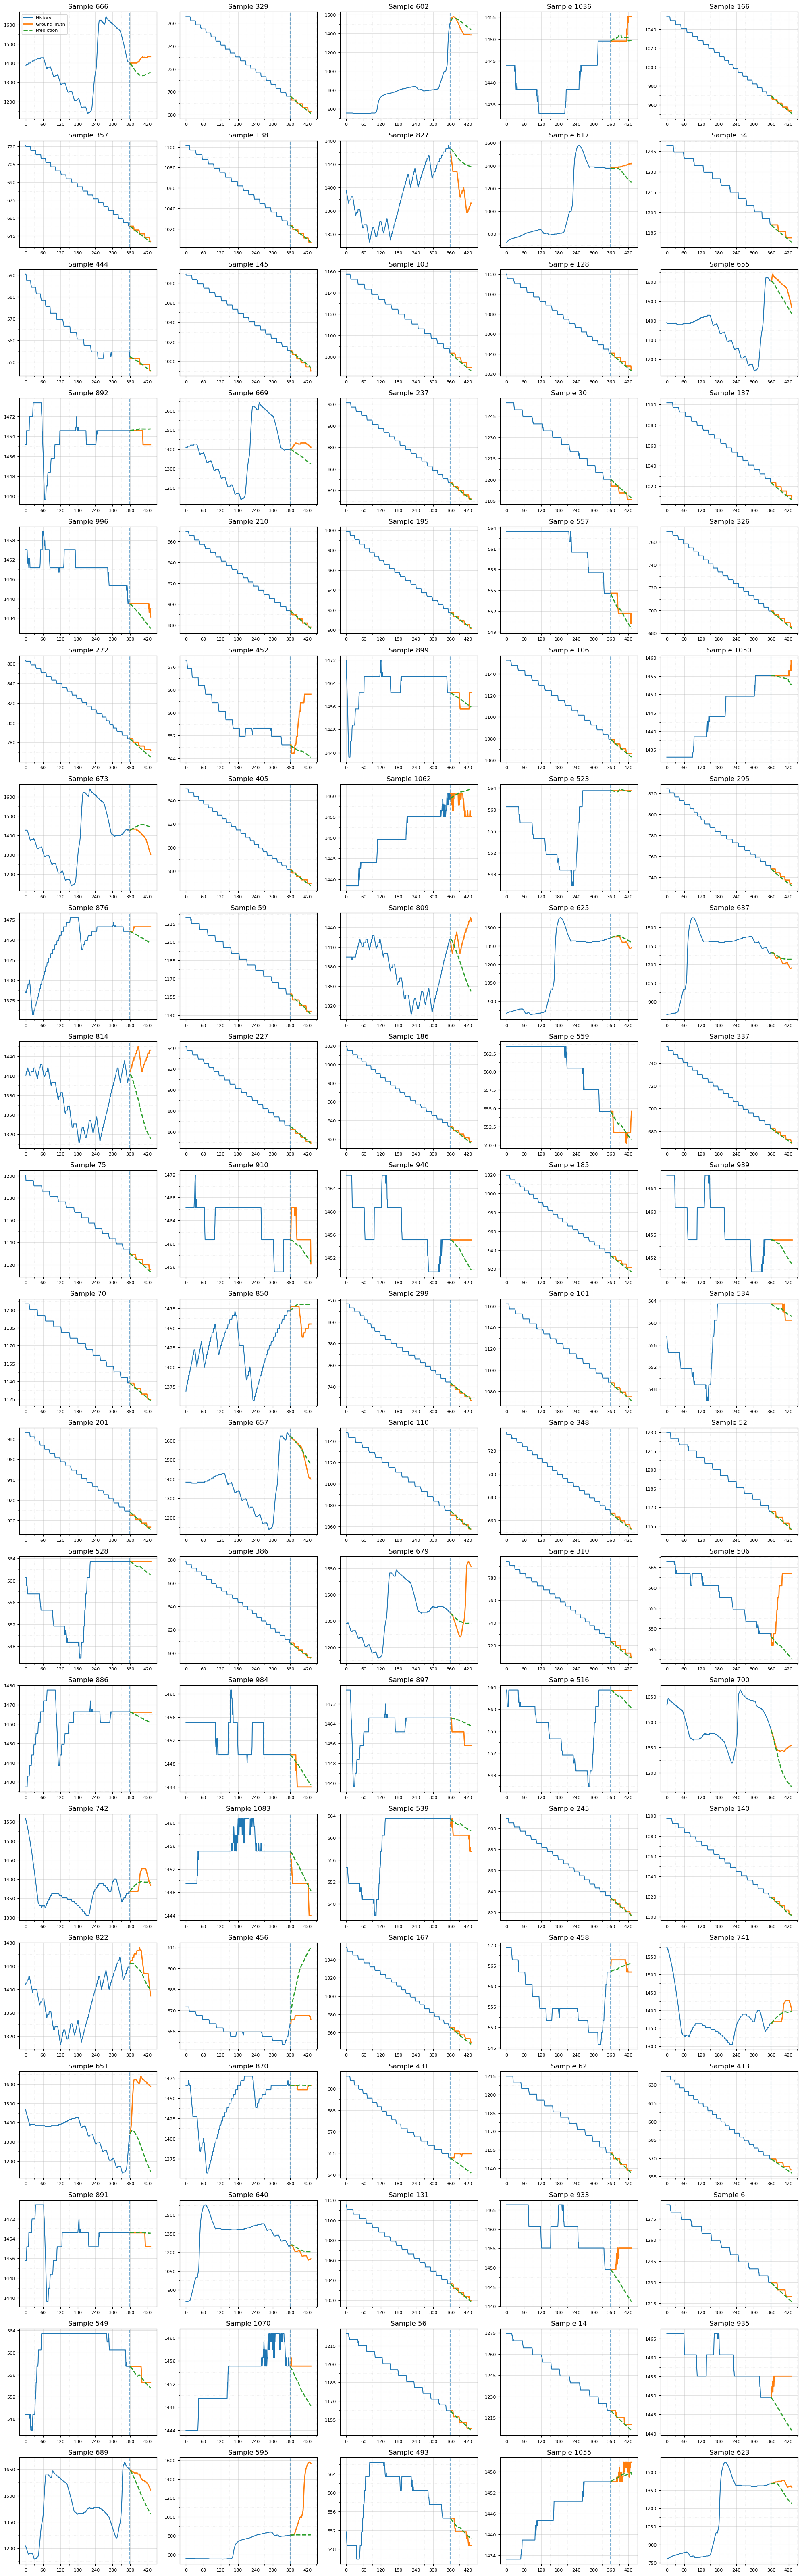

In [10]:
import torch
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import random

# ========= 1) 改成你项目里的真实模块路径 =========
from configs.ExtremeLSTMMemoConfig import ExtremeLSTMMemoConfig
from data_provider.DS3 import DS
from exp.exp_model import Model

# ========= 3) 初始化 config / data / model =========
config = ExtremeLSTMMemoConfig()
config.mode = "train"   # DS 在 mode='train' 时会自动构建 train/val/test loader
config.device = "cuda" if torch.cuda.is_available() else "cpu"
config.d_model = 128   # 必须和 checkpoint 一致
config.pred_len = 72   # 必须和 checkpoint 一致



# ========= 2) 读取你训练时用的原始数据 =========
# 这里的 trainX 必须是一个 DataFrame，并且至少包含:
# ['datetime', 'value']
trainX = pd.read_csv(
        "./datasets/" + config.dataset + "/" + config.reservoir_sensor + ".tsv", sep="\t"
    )
trainX.columns = ["datetime", "value"]
trainX.sort_values("datetime", inplace=True)



datamodule = DS(config, trainX)
model = Model(config)

# ========= 4) 加载权重 =========
ckpt_path = "./checkpoints/extreme_lstm_memo/Datasetwater_batchsize256_Modelextreme_lstm_memo_dmodel128_reservoirreservoir_stor_4001_sof24_epochs200_patience40_dropout0.3_SeqLen360_PredLen72_round_0.pt"
state = torch.load(ckpt_path, map_location="cpu", weights_only=True)
model.load_state_dict(state, strict=False)
model.to(config.device)
model.eval()

# ========= 5) 构建 retrieval index（和你正式 test 更一致） =========
try:
    model.prepare_retrieval_index(
        datamodule.train_data_loader.dataset,
        datamodule.train_data_loader
    )
except Exception as e:
    print("skip retrieval index:", e)

import random

# ========= 6) 跑完整个 test set，并保存历史 seq_len =========
all_hist_raw = []
all_pred_raw = []
all_real_raw = []

with torch.no_grad():
    for batch in datamodule.test_data_loader:
        x, x_mark, label, sample_ids, route_labels = batch

        x = x.to(config.device)
        x_mark = x_mark.to(config.device)
        label = label.to(config.device)
        sample_ids = sample_ids.to(config.device).long()

        # x 的第 2 列是 level_norm，把它还原成原始值，作为历史序列
        hist_raw = x[:, :, 1] * datamodule.level_std + datamodule.level_mean

        dec_input = torch.zeros_like(label[:, -config.pred_len:, :]).float()
        dec_input = torch.cat(
            [label[:, :config.label_len, :], dec_input],
            dim=1
        ).float().to(config.device)

        output, _ = model(
            x,
            x_mark,
            dec_input=dec_input,
            sample_ids=sample_ids,
            route_labels=None,
            mode="test"
        )

        pred_raw, real_raw = model._restore_to_raw(
            output["point_pred"],
            label,
            datamodule.mean,
            datamodule.std
        )

        all_hist_raw.append(hist_raw.detach().cpu())
        all_pred_raw.append(pred_raw.detach().cpu())
        all_real_raw.append(real_raw.detach().cpu())

all_hist_raw = torch.cat(all_hist_raw, dim=0)
all_pred_raw = torch.cat(all_pred_raw, dim=0)
all_real_raw = torch.cat(all_real_raw, dim=0)

# ========= 7) 从整个 test set 随机抽更多样本，并自动扩展画布 =========
num_show = 100
ncols = 5
nrows = (num_show + ncols - 1) // ncols

chosen_idx = random.sample(range(all_pred_raw.shape[0]), k=min(num_show, all_pred_raw.shape[0]))

fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 3.2 * nrows))
axes = axes.flatten() if hasattr(axes, "flatten") else [axes]

for ax, sample_idx in zip(axes, chosen_idx):
    hist_curve = all_hist_raw[sample_idx].numpy().squeeze()
    pred_curve = all_pred_raw[sample_idx].numpy().squeeze()
    real_curve = all_real_raw[sample_idx].numpy().squeeze()

    hist_x = range(len(hist_curve))
    fut_x = range(len(hist_curve), len(hist_curve) + len(real_curve))

    ax.plot(hist_x, hist_curve, label="History")
    ax.plot(fut_x, real_curve, label="Ground Truth", linewidth=2)
    ax.plot(fut_x, pred_curve, label="Prediction", linestyle="--", linewidth=2)

    ax.axvline(x=len(hist_curve)-1, linestyle="--", alpha=0.6)
    ax.set_title(f"Sample {sample_idx}")

    # 更细的坐标轴刻度：主刻度+次刻度
    ax.xaxis.set_major_locator(mticker.MaxNLocator(8))
    ax.xaxis.set_minor_locator(mticker.AutoMinorLocator(2))
    ax.yaxis.set_major_locator(mticker.MaxNLocator(6))
    ax.yaxis.set_minor_locator(mticker.AutoMinorLocator(2))
    ax.tick_params(axis="both", which="major", labelsize=8)
    ax.tick_params(axis="both", which="minor", length=2)

    ax.grid(which="major", alpha=0.35)
    ax.grid(which="minor", alpha=0.18, linestyle=":")

for ax in axes[len(chosen_idx):]:
    ax.axis("off")

axes[0].legend(fontsize=8)
plt.tight_layout()
plt.show()

In [1]:
import numpy as np

x = np.load("datasets/Abilene_12_12_3000.npy")
v = x[:, 3]
print(v.min(), v.max(), v.mean(), v.std())
print(np.quantile(v, [0, 0.5, 0.9, 0.99, 1]))

0.0 0.31429149 0.0032366352157835645 0.00520824777170854
[0.         0.00146695 0.0082575  0.02549775 0.31429149]
